In [1]:
import os
import cv2
import numpy as np
import torch
from torch.utils.data import Dataset, DataLoader
import segmentation_models_pytorch as smp
from tqdm import tqdm
import matplotlib.pyplot as plt
import json

In [ ]:
DATA_ROOT = r"E:\Education\4 course 2 semester\Diploma\panoptic_project\data\LaRS_fusion\semantic_deeplab3v+"

epochs = 30

In [3]:
def create_exp_dir():
    base_dir = r"E:\Education\4 course 2 semester\Diploma\panoptic_project\runs\semantic_segmentation\deeplab_30"
    os.makedirs(base_dir, exist_ok=True)

    existing = [
        d for d in os.listdir(base_dir)
        if os.path.isdir(os.path.join(base_dir, d)) and d.isdigit()
    ]

    if len(existing) == 0:
        exp_id = 1
    else:
        exp_id = max(map(int, existing)) + 1

    exp_dir = os.path.join(base_dir, str(exp_id))
    os.makedirs(exp_dir, exist_ok=True)

    os.makedirs(os.path.join(exp_dir, "checkpoints"), exist_ok=True)

    return exp_dir

In [4]:
def save_config(exp_dir, train_loader, val_loader, loss_fn, model, optimizer, epochs, img_size):
    config = {
        "img_size": img_size,

        "model_class": model.__class__.__name__,
        "loss": loss_fn.__class__.__name__,
        "optimizer": optimizer.__class__.__name__,

        "train_loader": {
            "batch_size": train_loader.batch_size,
            "shuffle": True,
            "num_workers": train_loader.num_workers,
            "pin_memory": train_loader.pin_memory,
            "drop_last": train_loader.drop_last
        },

        "val_loader": {
            "batch_size": val_loader.batch_size,
            "shuffle": True,
            "num_workers": val_loader.num_workers,
            "pin_memory": val_loader.pin_memory,
            "drop_last": val_loader.drop_last
        },

        "model": {
            "encoder_name": model.encoder_name if hasattr(model, "encoder_name") else "unknown",
            "in_channels": 3,
            "classes": 3
        },

        "optimizer_lr": optimizer.param_groups[0]["lr"],

        "epochs": epochs
    }

    with open(os.path.join(exp_dir, "config.json"), "w") as f:
        json.dump(config, f, indent=4)

In [5]:
def save_checkpoint(exp_dir, model, optimizer, epoch, loss, name="last.pth"):
    path = os.path.join(exp_dir, "checkpoints", name)

    torch.save({
        "epoch": epoch,
        "model_state_dict": model.state_dict(),
        "optimizer_state_dict": optimizer.state_dict(),
        "loss": loss
    }, path)

In [6]:
history = {
    "train_loss": [],
    "val_loss": []
}

In [ ]:
class LARSSemanticDataset(Dataset):
    def __init__(self, split, img_size=(640, 640)):
        self.img_dir = os.path.join(DATA_ROOT, split, "images")
        self.mask_dir = os.path.join(DATA_ROOT, split, "masks")
        self.images = sorted(os.listdir(self.img_dir))
        self.img_size = img_size
        self.mean = np.array([0.485, 0.456, 0.406], dtype=np.float32)
        self.std  = np.array([0.229, 0.224, 0.225], dtype=np.float32)

    def __len__(self):
        return len(self.images)

    def __getitem__(self, idx):
        name = self.images[idx]

        img_path = os.path.join(self.img_dir, name)
        base_name = os.path.splitext(name)[0]
        mask_path = os.path.join(self.mask_dir, base_name + ".png")

        image = cv2.imread(img_path)
        mask = cv2.imread(mask_path, cv2.IMREAD_GRAYSCALE)

        if image is None:
            raise ValueError(f"Image not found: {img_path}")

        if mask is None:
            raise ValueError(f"Mask not found: {mask_path}")

        image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)

        image = cv2.resize(image, self.img_size, interpolation=cv2.INTER_LINEAR)
        mask = cv2.resize(mask, self.img_size, interpolation=cv2.INTER_NEAREST)

        image = image.astype(np.float32) / 255.0

        image = (image - self.mean) / self.std

        image = torch.from_numpy(image).permute(2,0,1)
        mask = torch.from_numpy(mask).long()

        return image, mask

In [8]:
train_ds = LARSSemanticDataset("train")
val_ds = LARSSemanticDataset("val")

train_loader = DataLoader(train_ds, batch_size=4, shuffle=True, num_workers=0, pin_memory=True, drop_last=True)
val_loader = DataLoader(val_ds, batch_size=4, shuffle=False, num_workers=0, pin_memory=True, drop_last=True)

In [9]:
img, mask = train_ds[0]
print(np.unique(mask.numpy()))

[0 1 2]


In [10]:
model = smp.DeepLabV3Plus(
    encoder_name="resnet50",
    encoder_weights="imagenet",
    in_channels=3,
    classes=3
)

In [11]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(device)
model.to(device)

cuda


DeepLabV3Plus(
  (encoder): ResNetEncoder(
    (conv1): Conv2d(3, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3), bias=False)
    (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (relu): ReLU(inplace=True)
    (maxpool): MaxPool2d(kernel_size=3, stride=2, padding=1, dilation=1, ceil_mode=False)
    (layer1): Sequential(
      (0): Bottleneck(
        (conv1): Conv2d(64, 64, kernel_size=(1, 1), stride=(1, 1), bias=False)
        (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
        (conv2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
        (bn2): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
        (conv3): Conv2d(64, 256, kernel_size=(1, 1), stride=(1, 1), bias=False)
        (bn3): BatchNorm2d(256, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
        (relu): ReLU(inplace=True)
        (downsample): Sequentia

In [12]:
loss_fn = torch.nn.CrossEntropyLoss(ignore_index=255)
optimizer = torch.optim.Adam(model.parameters(), lr=1e-4)

In [ ]:
def train():
    exp_dir = create_exp_dir()
    save_config(
        exp_dir,
        train_loader,
        val_loader,
        loss_fn,
        model,
        optimizer,
        epochs,
        img_size=(640, 640)
    )

    history = {
        "train_loss": []
    }

    best_loss = float("inf")


    for epoch in range(epochs):
        model.train()
        total_loss = 0

        loop = tqdm(train_loader, desc=f"Epoch {epoch+1}/{epochs}")

        for images, masks in loop:
            
            images = images.to(device)
            masks = masks.to(device)

            preds = model(images)
            loss = loss_fn(preds, masks)

            optimizer.zero_grad()
            loss.backward()
            optimizer.step()
            
            total_loss += loss.item()
            loop.set_postfix(loss=loss.item())

        epoch_loss = total_loss / len(train_loader)
        history["train_loss"].append(epoch_loss)

        print(f"Epoch {epoch+1} loss: {epoch_loss:.4f}")

        save_checkpoint(exp_dir, model, optimizer, epoch, epoch_loss, "last.pth")

        if epoch_loss < best_loss:
            best_loss = epoch_loss
            save_checkpoint(exp_dir, model, optimizer, epoch, epoch_loss, "best.pth")

    with open(os.path.join(exp_dir, "history.json"), "w") as f:
        json.dump(history, f, indent=4)

if __name__ == "__main__":
    train()

Epoch 1/30: 100%|██████████| 651/651 [08:55<00:00,  1.22it/s, loss=0.0559]


Epoch 1 loss: 0.1227


Epoch 2/30: 100%|██████████| 651/651 [07:47<00:00,  1.39it/s, loss=0.238] 


Epoch 2 loss: 0.0621


Epoch 3/30: 100%|██████████| 651/651 [07:14<00:00,  1.50it/s, loss=0.028] 


...

Epoch 28 loss: 0.0166


Epoch 29/30: 100%|██████████| 651/651 [07:14<00:00,  1.50it/s, loss=0.0263] 


Epoch 29 loss: 0.0248


Epoch 30/30: 100%|██████████| 651/651 [07:14<00:00,  1.50it/s, loss=0.0236] 


Epoch 30 loss: 0.0198


In [14]:
def compute_iou_per_class(model, dataloader, device, num_classes=3):
    model.eval()

    intersection = np.zeros(num_classes)
    union = np.zeros(num_classes)

    with torch.no_grad():
        for images, masks in tqdm(dataloader):
            images = images.to(device)
            masks = masks.to(device)

            preds = model(images)
            preds = torch.argmax(preds, dim=1)

            for cls in range(num_classes):
                pred_cls = (preds == cls)
                mask_cls = (masks == cls)

                inter = (pred_cls & mask_cls).sum().item()
                u = (pred_cls | mask_cls).sum().item()

                intersection[cls] += inter
                union[cls] += u

    iou = intersection / (union + 1e-6)
    return iou

In [15]:
ious = compute_iou_per_class(model, val_loader, device)

class_names = ["water", "sky", "obstacle"]

for i, name in enumerate(class_names):
    print(f"{name}: IoU = {ious[i]:.4f}")

100%|██████████| 49/49 [00:16<00:00,  2.98it/s]

water: IoU = 0.9367
sky: IoU = 0.9728
obstacle: IoU = 0.9771


In [16]:
# model.eval()

# iou_scores = []

# with torch.no_grad():
#     for images, masks in val_loader:
#         images = images.to(device)
#         masks = masks.to(device)

#         preds = model(images)
#         preds = torch.argmax(preds, dim=1)

#         iou = (preds == masks).float().mean()
#         iou_scores.append(iou.item())

# print("Val IoU:", sum(iou_scores)/len(iou_scores))
# print()

In [ ]:
deeplab_model = smp.DeepLabV3Plus(
    encoder_name="resnet50",
    encoder_weights=None,
    in_channels=3,
    classes=3
)

deeplab_model.load_state_dict(torch.load(r"E:\Education\4 course 2 semester\Diploma\panoptic_project\runs\semantic_segmentation\deeplab_30\2\deeplab_lars_30.pth"))
deeplab_model = deeplab_model.cuda()

In [ ]:
ious = compute_iou_per_class(model, val_loader, device)

class_names = ["water", "sky", "obstacle"]

for i, name in enumerate(class_names):
    print(f"{name}: IoU = {ious[i]:.4f}")

miou = np.mean(ious)
print("\nmIoU:", miou)


correct = 0
total = 0

model.eval()

with torch.no_grad():
    for images, masks in val_loader:
        images = images.to(device)
        masks = masks.to(device)

        preds = model(images)
        preds = torch.argmax(preds, dim=1)

        correct += (preds == masks).sum().item()
        total += masks.numel()

pixel_acc = correct / total

print("Pixel Accuracy:", pixel_acc)

100%|██████████| 49/49 [00:14<00:00,  3.49it/s]


water: IoU = 0.9367
sky: IoU = 0.9728
obstacle: IoU = 0.9771

mIoU: 0.9622232981388907
Pixel Accuracy: 0.9814467200454401


In [ ]:
COLORS = {
    0: (0, 0, 255),
    1: (135, 206, 235),
    2: (0, 255, 0)     
}

def visualize_prediction(model, dataset, device, idx=0):
    model.eval()

    image, mask = dataset[idx]

    with torch.no_grad():
        pred = model(image.unsqueeze(0).to(device))
        pred = torch.argmax(pred, dim=1).squeeze().cpu().numpy()
    

    mean = np.array([0.485, 0.456, 0.406], dtype=np.float32)[:, None, None]
    std  = np.array([0.229, 0.224, 0.225], dtype=np.float32)[:, None, None]
    image = image.detach().cpu()
    image = image * std + mean
    image = image.permute(1, 2, 0).numpy()
    image_np = np.clip(image, 0, 1)

    color_mask = np.zeros_like(image_np)

    for cls, color in COLORS.items():
        color_mask[pred == cls] = np.array(color) / 255.0

    overlay = 0.6 * image_np + 0.4 * color_mask

    plt.figure(figsize=(15,5))

    plt.subplot(1,3,1)
    plt.title("Image")
    plt.imshow(image_np)
    plt.axis("off")

    plt.subplot(1,3,2)
    plt.title("Ground Truth")
    gt_mask = np.zeros_like(image_np)
    for cls, color in COLORS.items():
        gt_mask[mask.numpy() == cls] = np.array(color) / 255.0
    plt.imshow(image_np)
    plt.imshow(gt_mask)
    plt.axis("off")

    plt.subplot(1,3,3)
    plt.title("Prediction")
    plt.imshow(overlay)
    plt.axis("off")

    plt.show()

C:\Users\follo\AppData\Local\Temp\ipykernel_2920\3985717086.py:20: DeprecationWarning: __array_wrap__ must accept context and return_scalar arguments (positionally) in the future. (Deprecated NumPy 2.0)
  image = image * std + mean


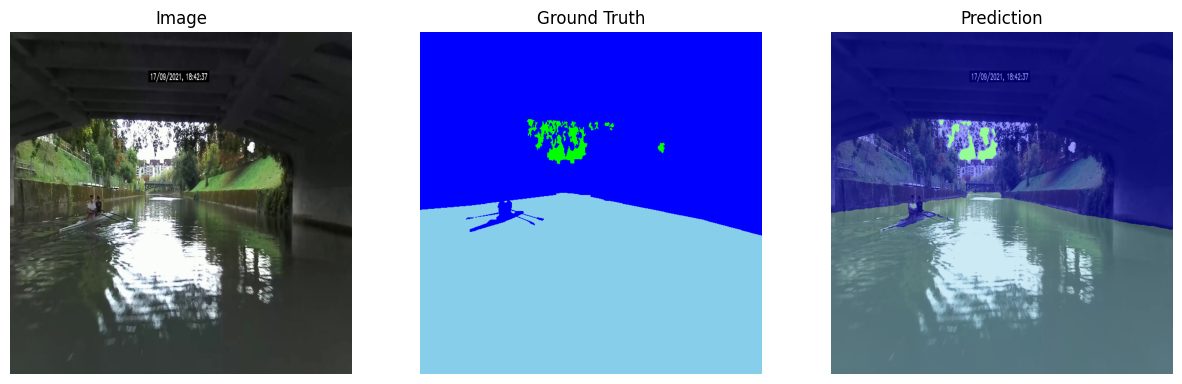

In [26]:
visualize_prediction(model, val_ds, device, idx=10)

In [ ]:
torch.save(model.state_dict(), f"{create_exp_dir()}\deeplab_lars_30.pth")

In [ ]:
print("Обучение DeepLab завершено!")

Обучение DeepLab завершено!
